# TP N°1 — Simulation de variables aleatoires

**On rappelle ici quelques méthodes utiles pour la simulation de variables aléatoires. Ces méthodes seront par la suite revues et étendues pour la simulation de processus stochastique, il est donc nécessaire de bien les connaître. On utilisera ici le langage de programmation Python, la bibliothèque NumPy pour les opérations mathématiques et simulations de variables aléatoires, et la bibliothèque Matplotlib pour la visualisation des résultats. Tous les programmes commenceront donc par les lignes de commande suivantes**

In [2]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

## Exercice 1 — Loi uniforme

1) Executer plusieurs fois le code ci-dessous et expliquer les resultats.

In [3]:
for i in range(3):
    print("#" * 20)
    print(npr.rand())
    print(npr.rand())

    npr.seed(seed=1)
    print(npr.rand())
    print(npr.rand())

    npr.seed(seed=1)
    print(npr.rand())
    print(npr.rand())
    print("#" * 20)

####################
0.2923604493446481
0.9294075925457618
0.417022004702574
0.7203244934421581
0.417022004702574
0.7203244934421581
####################
####################
0.00011437481734488664
0.30233257263183977
0.417022004702574
0.7203244934421581
0.417022004702574
0.7203244934421581
####################
####################
0.00011437481734488664
0.30233257263183977
0.417022004702574
0.7203244934421581
0.417022004702574
0.7203244934421581
####################


# Explication du code

Le code initialise des variables et démontre l'effet de la fonction `seed()` sur la génération de nombres aléatoires. Lorsqu'une graine est définie, la même séquence de nombres aléatoires est produite à chaque fois. Cela illustre que `npr.rand()` génère des nombres pseudo-aléatoires qui sont déterministes une fois la graine fixée.

Chaque itération de la boucle affiche :
- Deux nombres aléatoires différents (sans graine définie)
- Deux nombres identiques générés après avoir défini `seed=1`
- Les mêmes deux nombres reproduits après avoir réappelé `seed=1`

Cela montre que la graine réinitialise le générateur de nombres aléatoires, permettant la **reproductibilité** des résultats en recherche scientifique et en débogage.

2) La fonction `npr.rand` peut prendre des arguments optionnels. Que renvoient les appels suivants ?
- `npr.rand(10)`
- `npr.rand(5, 3)`
- `npr.rand(2, 3, 4)`
- `npr.rand((2, 3, 4))`

**Reponse :**

In [6]:
print("#" * 20)
print("npr.rand(10) shape:", npr.rand(10))
print("#" * 20)
print("npr.rand(5, 3) shape:", npr.rand(5, 3))
print("#" * 20)
print("npr.rand(2, 3, 4) shape:", npr.rand(2, 3, 4))
print("#" * 20)

####################
npr.rand(10) shape: [0.94082796 0.68421805 0.06491159 0.87042486 0.70138029 0.60492687
 0.7323749  0.25343904 0.60048896 0.81461918]
####################
npr.rand(5, 3) shape: [[0.05411366 0.13051067 0.84244581]
 [0.61834587 0.53128781 0.24829073]
 [0.29507858 0.87268616 0.42166593]
 [0.06443026 0.89698507 0.20338083]
 [0.82622754 0.88177062 0.48675074]]
####################
npr.rand(2, 3, 4) shape: [[[0.59846469 0.52726746 0.62482129 0.85504172]
  [0.28213945 0.88375551 0.56769033 0.11510304]
  [0.22700117 0.59598239 0.23944624 0.13141566]]

 [[0.16184771 0.84487252 0.60218365 0.96356709]
  [0.34567921 0.5956251  0.59898529 0.61570429]
  [0.05917721 0.75031718 0.9482095  0.53467906]]]
####################


3) Executer le code ci-dessous et commenter les resultats.

**Reponse :**

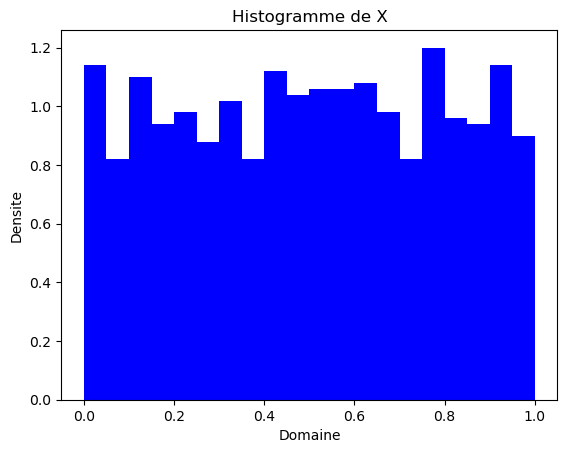

In [5]:
X = npr.rand(1000)
plt.hist(X, bins=20, range=(0, 1), density=True, color="blue")
plt.xlabel("Domaine")
plt.ylabel("Densite")
plt.title("Histogramme de X")
plt.show()

## Exercice 2 — De equilibre

On lance un de bien equilibre. On note $D$ la variable aleatoire egale au resultat.

1) Quelle est la loi de $D$ ? Quelle est son esperance $\mu$ et sa variance $\sigma^2$ ?

**Reponse :**

La loi de $D$ est **uniforme discrète** sur $\{1, 2, 3, 4, 5, 6\}$.

**Espérance :** $\mu = \mathbb{E}[D] = \frac{1+2+3+4+5+6}{6} = \frac{21}{6} = 3.5$

**Variance :** $\sigma^2 = \text{Var}(D) = \mathbb{E}[D^2] - (\mathbb{E}[D])^2 = \frac{1+4+9+16+25+36}{6} - (3.5)^2 = \frac{91}{6} - 12.25 = \frac{35}{12} \approx 2.917$

2) Creer une fonction `desfaces(N)` qui renvoie un vecteur ligne de taille $N$ dont les composantes sont des copies i.i.d. de $D$.

**Reponse :**

In [7]:
def desfaces(N):
    # Tirages i.i.d. uniformes sur {1,2,3,4,5,6}
    return npr.randint(1, 7, size=N)

3) Tracer l'histogramme d'un echantillon de taille $N = 1000$ et afficher sa moyenne empirique.

**Reponse :**

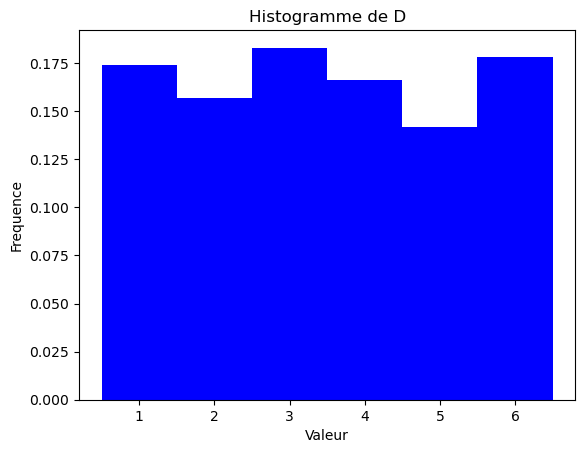

In [9]:
N = 1000
X = desfaces(N)
plt.hist(X, bins=np.arange(0.5, 6.6, 1.0), density=True, color="blue")
plt.xlabel("Valeur")
plt.ylabel("Frequence")
plt.title("Histogramme de D")
plt.show()

4) Ecrire une fonction `moy_exp(X)` qui renvoie la moyenne empirique d'un echantillon $X$.

**Reponse :**

In [16]:
def moy_exp(X):
    return np.mean(X)

In [17]:
print(f"moyenne empirique: {moy_exp(X)}")

moyenne empirique: 3.479


5) Calculer la moyenne empirique d'un echantillon de $N = 10000$ valeurs suivant la loi de $D$. Donner une prediction theorique et justifier la reponse.

**Reponse :** *(a completer)*

In [ ]:
N = 10000
X = desfaces(N)
print("Moyenne empirique N=10000:", moy_exp(X))
print("Moyenne theorique:", 3.5)

## Exercice 3 — Loi uniforme discrete

Soient $n$ et $m$ deux entiers tels que $n < m$. On rappelle : si $U \sim \mathcal{U}((0,1))$, alors $V = n + \lfloor (m-n) U \rfloor$ suit $\mathcal{U}(\{n, n+1, \dots, m-1\})$.

1) Ecrire une fonction `uniforme(n, m)` simulant la loi $\mathcal{U}(\{n,\dots,m-1\})$.

**Reponse :**

In [ ]:
def uniforme(n, m):
    u = npr.rand()
    return n + int(np.floor((m - n) * u))

2) Completer la fonction `Uniforme(n, m, N)` afin qu'elle renvoie un vecteur contenant $N$ realisations independantes de `uniforme(n, m)`.

**Reponse :** *(a completer)*

In [ ]:
def Uniforme(n, m, N):
    v = np.zeros(N, dtype=int)
    for k in range(N):
        v[k] = uniforme(n, m)
    return v

print(Uniforme(2, 7, 10))

## Exercice 4 — Loi de Bernoulli

Pour simuler une loi de Bernoulli, on tire un nombre $u$ dans $[0,1]$ via `rand()`.
- Si $u < p$, on renvoie 1.
- Sinon, on renvoie 0.

<img src="bernoulli.png" width="700">

1) Completer la fonction suivante :
```python
    def bernoulli(p):
        u = 0
        if ...:
            u = ...
        return u
```

**Reponse :** *(a completer)*

In [ ]:
def bernoulli(p):
    u = 0
    if npr.rand() < p:
        u = 1
    return u

2) Ecrire une fonction `Bernoulli(p, N)` renvoyant un vecteur contenant $N$ realisations independantes de la loi $B(p)$.

**Reponse :** *(a completer)*

In [ ]:
def Bernoulli(p, N):
    return np.array([bernoulli(p) for _ in range(N)], dtype=int)

print(Bernoulli(0.3, 10))

## Exercice 5 — Loi binomiale $B(n, p)$

1) Ecrire une fonction `Binom(n, p)` simulant la loi $B(n, p)$.

**Reponse :** *(a completer)*

In [ ]:
def Binom(n, p):
    return int(np.sum(Bernoulli(p, n)))

2) Ecrire une fonction `Binomiale(n, p, N)` donnant un echantillon de taille $N$ de $B(n, p)$.

**Reponse :** *(a completer)*

In [ ]:
def Binomiale(n, p, N):
    return np.array([Binom(n, p) for _ in range(N)], dtype=int)

print(Binomiale(5, 0.4, 10))

## Exercice 6 — Loi geometrique $G(p)$

1) Ecrire une fonction `geom(p)` simulant $G(p)$.

**Reponse :** *(a completer)*

In [ ]:
def geom(p):
    # Geometrique sur {1,2,3,...} (nombre d'essais jusqu'au premier succes)
    u = npr.rand()
    return int(np.floor(np.log(1 - u) / np.log(1 - p))) + 1

2) Ecrire une fonction `Geom(p, N)` simulant un echantillon de taille $N$.

**Reponse :** *(a completer)*

In [ ]:
def Geom(p, N):
    return np.array([geom(p) for _ in range(N)])

3) Simuler un echantillon de taille $N = 10000$ de la loi $G(0.2)$, puis verifier la coherence de la moyenne.

**Reponse :** *(a completer)*

In [ ]:
N = 10000
sample = Geom(0.2, N)
print("Moyenne empirique:", sample.mean())
print("Moyenne theorique:", 1 / 0.2)

## Exercice 7 — Geometrique via exponentielle

1) Si $X \sim \mathrm{Exp}(\lambda)$, montrer que $Y = \lfloor X \rfloor + 1$ suit $G(1 - e^{-\lambda})$.

**Reponse :** *(a completer)*

2) Ecrire une fonction `Geom2(p, N)` simulant un echantillon de taille $N$ de $G(p)$ a partir d'une exponentielle.

**Reponse :** *(a completer)*

In [ ]:
def Geom2(p, N):
    # p = 1 - exp(-lambda) => lambda = -log(1-p)
    lbda = -np.log(1 - p)
    X = npr.exponential(1 / lbda, size=N)
    return np.floor(X).astype(int) + 1

3) Comparer `Geom` et `Geom2` pour $p=0.3$ via histogrammes et diagramme en batons theorique.

**Reponse :** *(a completer)*

In [ ]:
p = 0.3
N = 10000
sample_geom = Geom(p, N)
sample_geom2 = Geom2(p, N)

max_k = 20
k_vals = np.arange(1, max_k + 1)
pmf = p * (1 - p) ** (k_vals - 1)

plt.figure(figsize=(9, 4))
plt.subplot(1, 3, 1)
plt.hist(sample_geom, bins=np.arange(1, max_k + 2), density=True, color="blue")
plt.title("Geom")
plt.subplot(1, 3, 2)
plt.hist(sample_geom2, bins=np.arange(1, max_k + 2), density=True, color="green")
plt.title("Geom2")
plt.subplot(1, 3, 3)
plt.bar(k_vals, pmf, color="red")
plt.title("PMF theorique")
plt.tight_layout()
plt.show()

## Exercice 8 — Methode d'inversion

1) Montrer que $F(X)$ suit une loi uniforme sur $[0,1]$.

**Reponse :** *(a completer)*

2) En deduire que si $U$ est uniforme, alors $F^{-1}(U)$ a meme loi que $X$.

**Reponse :** *(a completer)*

3) Rappeler la fonction de repartition d'une exponentielle de parametre $\lambda$ et en deduire une methode de generation.

**Reponse :** *(a completer)*

4) Construire `loiExpo(n, lbda)` qui retourne un tableau NumPy de $n$ v.a. i.i.d. exponentielles.

**Reponse :** *(a completer)*

In [20]:
def loiExpo(n, lbda):
    u = npr.rand(n)
    return -np.log(1 - u) / lbda

5) Verifier avec l'histogramme.

**Reponse :** *(a completer)*

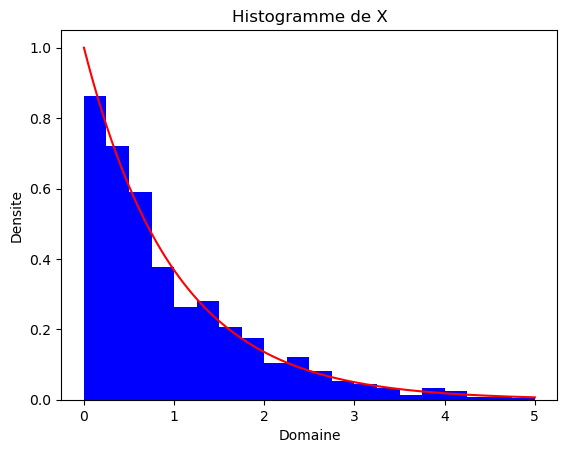

In [22]:
X = loiExpo(1000, 1.0)
plt.hist(X, bins=20, range=(0, 5), density=True, color="blue")
position = np.linspace(0, 5, 200)
plt.plot(position, np.exp(-position), color="red")
plt.xlabel("Domaine")
plt.ylabel("Densite")
plt.title("Histogramme de X")
plt.show()

6) (*) Definir `loiCauchy(n, a, b)` de densite $\frac{b}{\pi(b^2 + (x-a)^2)}$.

**Reponse :** *(a completer)*

In [21]:
def loiCauchy(n, a, b):
    u = npr.rand(n)
    return a + b * np.tan(np.pi * (u - 0.5))

## Exercice 9 — Densite $f(x) = 3x^2$ sur $[0,1]$

1) Justifier que $f$ est une densite.
2) Verifier que la fonction de repartition est $F(x) = x^3$ sur $[0,1]$.
3) Simuler $X$ par la methode d'inversion et tracer l'histogramme.

**Reponse :** *(a completer)*

In [ ]:
def rep(N):
    u = npr.rand(N)
    return u ** (1 / 3)

X = rep(1000)
plt.hist(X, bins=20, range=(0, 1), density=True, color="blue")
plt.xlabel("Domaine")
plt.ylabel("Densite")
plt.title("Histogramme de X")
plt.show()

## Exercice 10 — Densite $f(x) = 1/(x \ln 2)$ sur $[1,2]$

On admet que $f$ est une densite et que
$$
F(x) = \begin{cases}
0, & x < 1 \\
\ln(x)/\ln(2), & 1 \le x < 2 \\
1, & x \ge 2
\end{cases}
$$

1) Resoudre pour $u \in [0,1]$ l'equation $F(x) = u$ (avec $x \in [1,2]$).
2) Ecrire `inv_repartition(N)` qui retourne un echantillon de taille $N$.

**Reponse :** *(a completer)*

In [ ]:
def inv_repartition(N):
    u = npr.rand(N)
    return 2 ** u

X = inv_repartition(1000)
plt.hist(X, bins=20, range=(1, 2), density=True, color="blue")
plt.xlabel("Domaine")
plt.ylabel("Densite")
plt.title("Histogramme de X")
plt.show()